# Exploratory Data Analysis

In [1]:
import sys
sys.path.append("..")          # so we can import from src/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import RAW_FILE, SNAPSHOT_DATE

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")

%matplotlib inline

In [2]:
df = pd.read_csv(RAW_FILE)
print(f"Shape: {df.shape}")
df.head()

Shape: (95662, 16)


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0000,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0000,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0000,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0000,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0000,644,2018-11-15T03:34:21Z,2,0


In [3]:
# dtypes and null counts in one view
overview = pd.DataFrame({
    "dtype"   : df.dtypes,
    "n_null"  : df.isnull().sum(),
    "pct_null": (df.isnull().sum() / len(df) * 100).round(2),
    "n_unique": df.nunique()
})
print(overview)

                        dtype  n_null  pct_null  n_unique
TransactionId          object       0    0.0000     95662
BatchId                object       0    0.0000     94809
AccountId              object       0    0.0000      3633
SubscriptionId         object       0    0.0000      3627
CustomerId             object       0    0.0000      3742
CurrencyCode           object       0    0.0000         1
CountryCode             int64       0    0.0000         1
ProviderId             object       0    0.0000         6
ProductId              object       0    0.0000        23
ProductCategory        object       0    0.0000         9
ChannelId              object       0    0.0000         4
Amount                float64       0    0.0000      1676
Value                   int64       0    0.0000      1517
TransactionStartTime   object       0    0.0000     94556
PricingStrategy         int64       0    0.0000         4
FraudResult             int64       0    0.0000         2


In [14]:
df.describe(include="all")

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
count,95662,95662,95662,95662,95662,95662,95662.0000,95662,95662,95662,95662,95662.0000,95662.0000,95662,95662.0000,95662.0000
unique,95662,94809,3633,3627,3742,1,NaN,6,23,9,4,NaN,NaN,NaN,NaN,NaN
top,TransactionId_76871,BatchId_67019,AccountId_4841,SubscriptionId_3829,CustomerId_7343,UGX,NaN,ProviderId_4,ProductId_6,financial_services,ChannelId_3,NaN,NaN,NaN,NaN,NaN
freq,1,28,30893,32630,4091,95662,NaN,38189,32635,45405,56935,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,256.0000,NaN,NaN,NaN,NaN,6717.8464,9900.5839,2019-01-02 01:15:52.886433536+00:00,2.2560,0.0020
min,NaN,NaN,NaN,NaN,NaN,NaN,256.0000,NaN,NaN,NaN,NaN,-1000000.0000,2.0000,2018-11-15 02:18:49+00:00,0.0000,0.0000
25%,NaN,NaN,NaN,NaN,NaN,NaN,256.0000,NaN,NaN,NaN,NaN,-50.0000,275.0000,2018-12-12 09:47:57.750000128+00:00,2.0000,0.0000
50%,NaN,NaN,NaN,NaN,NaN,NaN,256.0000,NaN,NaN,NaN,NaN,1000.0000,1000.0000,2018-12-31 17:20:45+00:00,2.0000,0.0000
75%,NaN,NaN,NaN,NaN,NaN,NaN,256.0000,NaN,NaN,NaN,NaN,2800.0000,5000.0000,2019-01-25 10:54:47.500000+00:00,2.0000,0.0000
max,NaN,NaN,NaN,NaN,NaN,NaN,256.0000,NaN,NaN,NaN,NaN,9880000.0000,9880000.0000,2019-02-13 10:01:28+00:00,4.0000,1.0000


In [17]:
# For categorical columns
df.describe(include="object")

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,ProviderId,ProductId,ProductCategory,ChannelId
count,95662,95662,95662,95662,95662,95662,95662,95662,95662,95662
unique,95662,94809,3633,3627,3742,1,6,23,9,4
top,TransactionId_76871,BatchId_67019,AccountId_4841,SubscriptionId_3829,CustomerId_7343,UGX,ProviderId_4,ProductId_6,financial_services,ChannelId_3
freq,1,28,30893,32630,4091,95662,38189,32635,45405,56935


Earliest transaction: 2018-11-15 02:18:49+00:00
Latest transaction  : 2019-02-13 10:01:28+00:00
Date range (days)   : 90


C:\Users\Antifragile\AppData\Local\Temp\ipykernel_16868\3155891319.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df.groupby(df["TransactionStartTime"].dt.to_period("M")).size().plot(


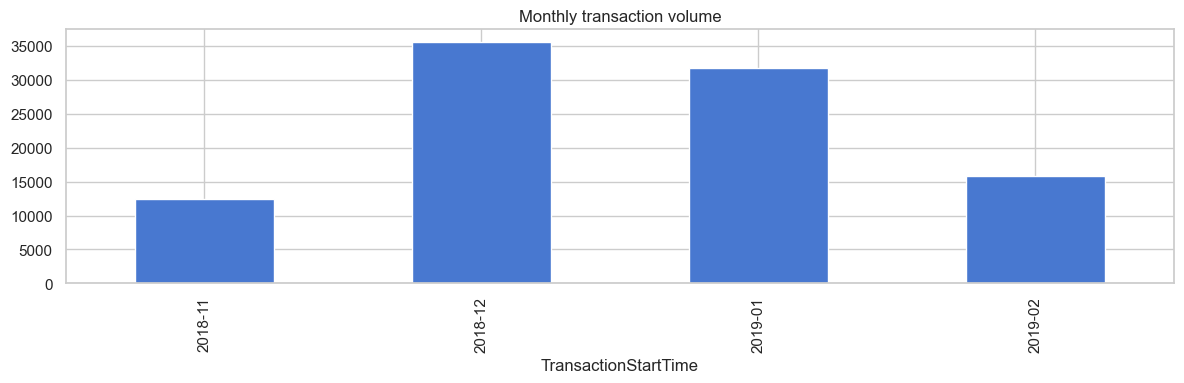

In [5]:
df["TransactionStartTime"] = pd.to_datetime(df["TransactionStartTime"])

print("Earliest transaction:", df["TransactionStartTime"].min())
print("Latest transaction  :", df["TransactionStartTime"].max())
print("Date range (days)   :", (df["TransactionStartTime"].max() - df["TransactionStartTime"].min()).days)

# Monthly transaction volume — tells you where data is dense
df.groupby(df["TransactionStartTime"].dt.to_period("M")).size().plot(
    kind="bar", figsize=(12, 4), title="Monthly transaction volume"
)
plt.tight_layout()

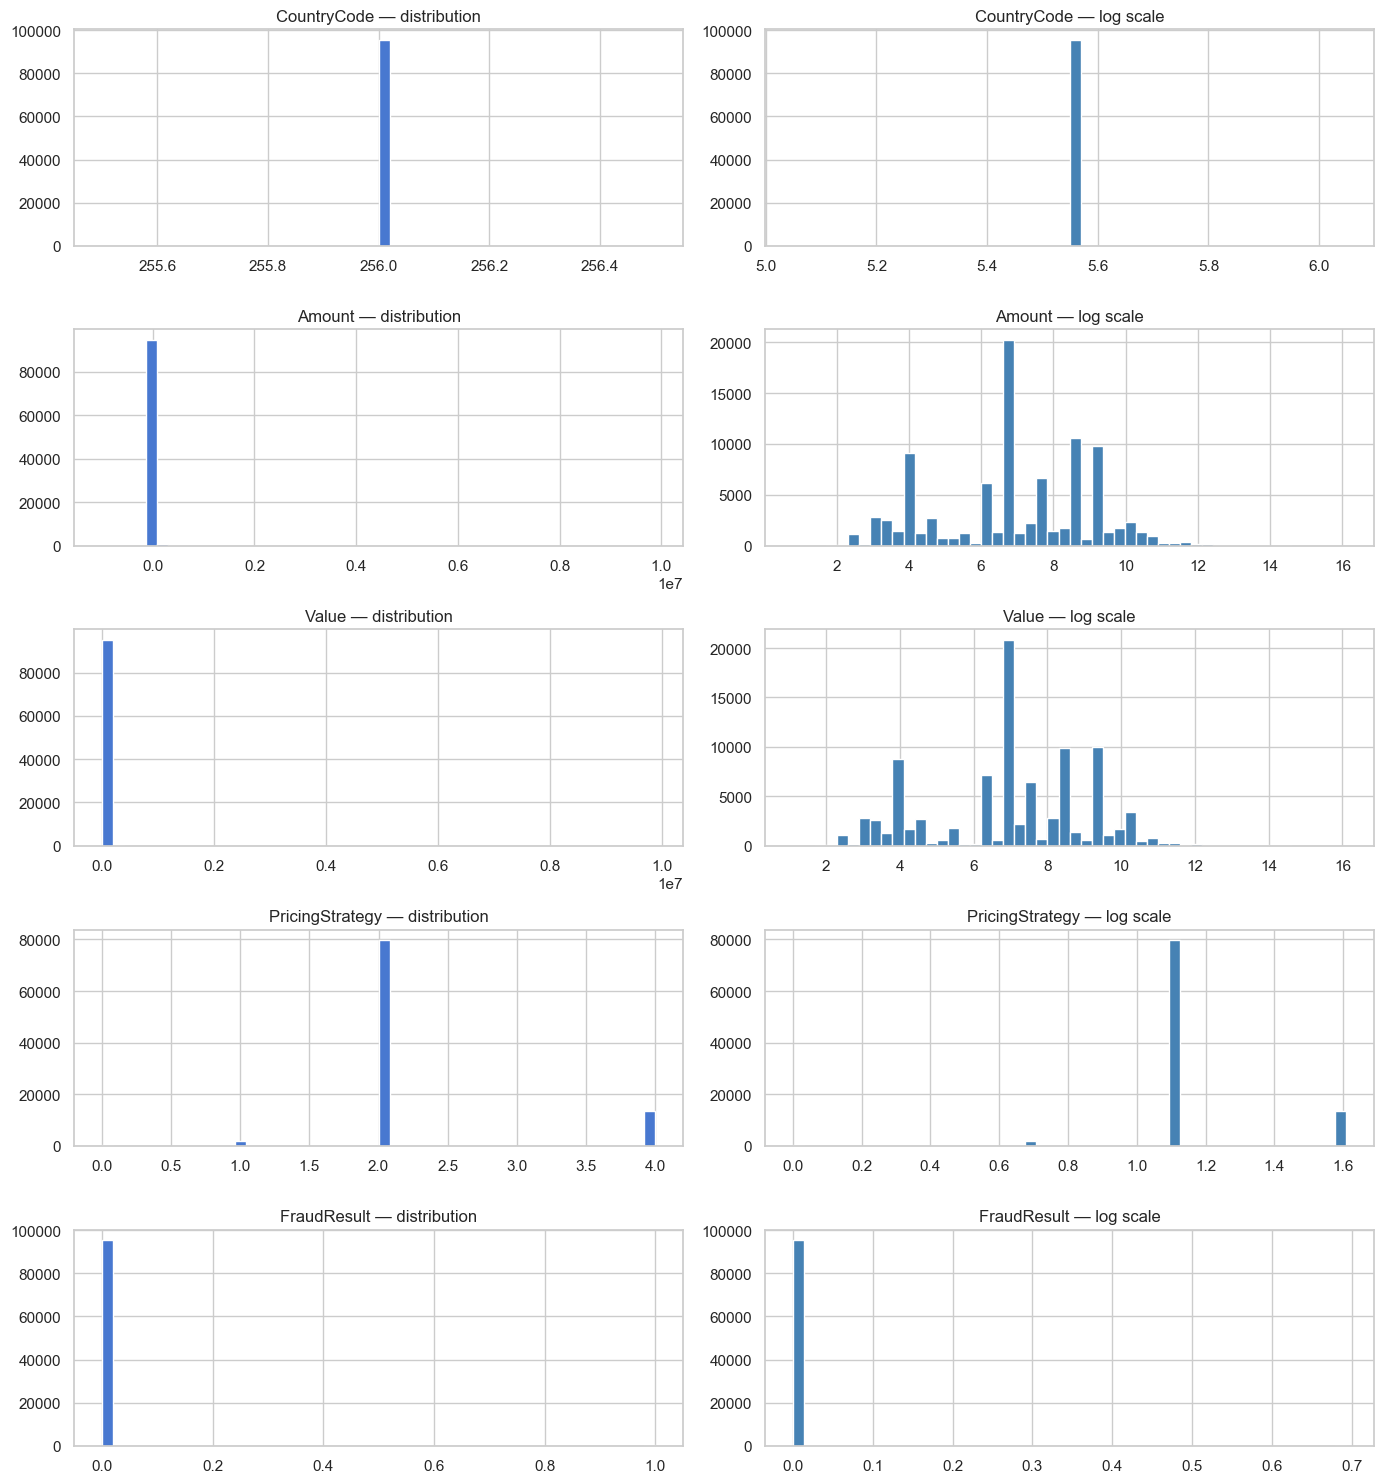

In [6]:
num_cols = df.select_dtypes(include="number").columns.tolist()

fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, len(num_cols) * 3))

for i, col in enumerate(num_cols):
    # histogram
    df[col].hist(bins=50, ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} — distribution")
    # log-scale version for skewed features
    df[col].apply(lambda x: np.log1p(abs(x))).hist(bins=50, ax=axes[i, 1], color="steelblue")
    axes[i, 1].set_title(f"{col} — log scale")

plt.tight_layout()

In [16]:
# Check for skewness
print("Skewness of numerical features:")
for col in num_cols:
    skew = df[col].skew()
    print(f"{col}: {skew:.2f}")

Skewness of numerical features:
CountryCode: 0.00
Amount: 51.10
Value: 51.29
PricingStrategy: 1.66
FraudResult: 22.20


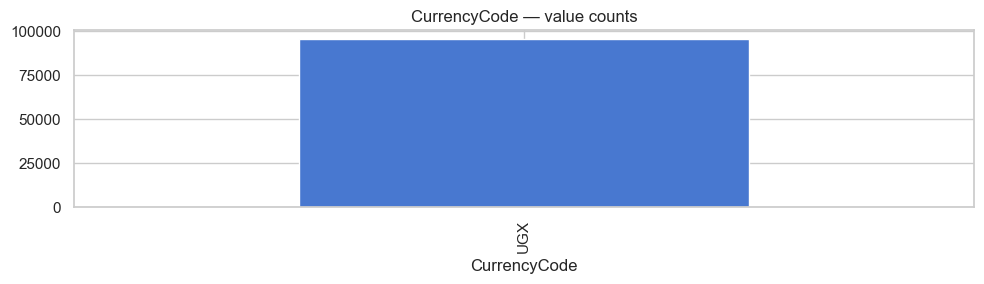

CurrencyCode: 1 unique values



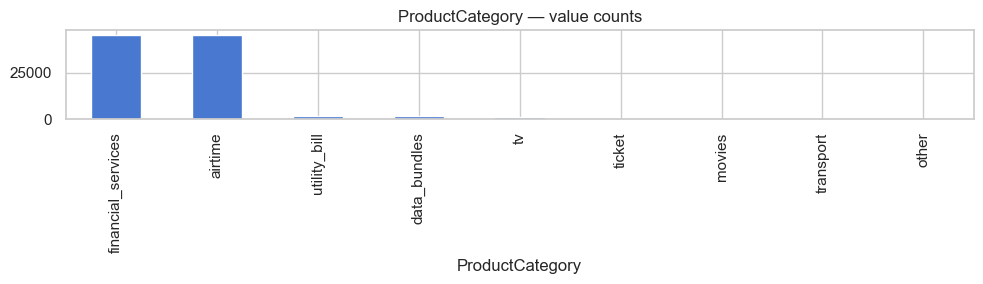

ProductCategory: 9 unique values



In [7]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
# Remove ID columns — they have unique values per row, no distribution to show
id_cols  = [c for c in cat_cols if "Id" in c or "id" in c]
cat_cols = [c for c in cat_cols if c not in id_cols]

for col in cat_cols:
    fig, ax = plt.subplots(figsize=(10, 3))
    df[col].value_counts().plot(kind="bar", ax=ax, title=f"{col} — value counts")
    plt.tight_layout()
    plt.show()
    print(f"{col}: {df[col].nunique()} unique values\n")

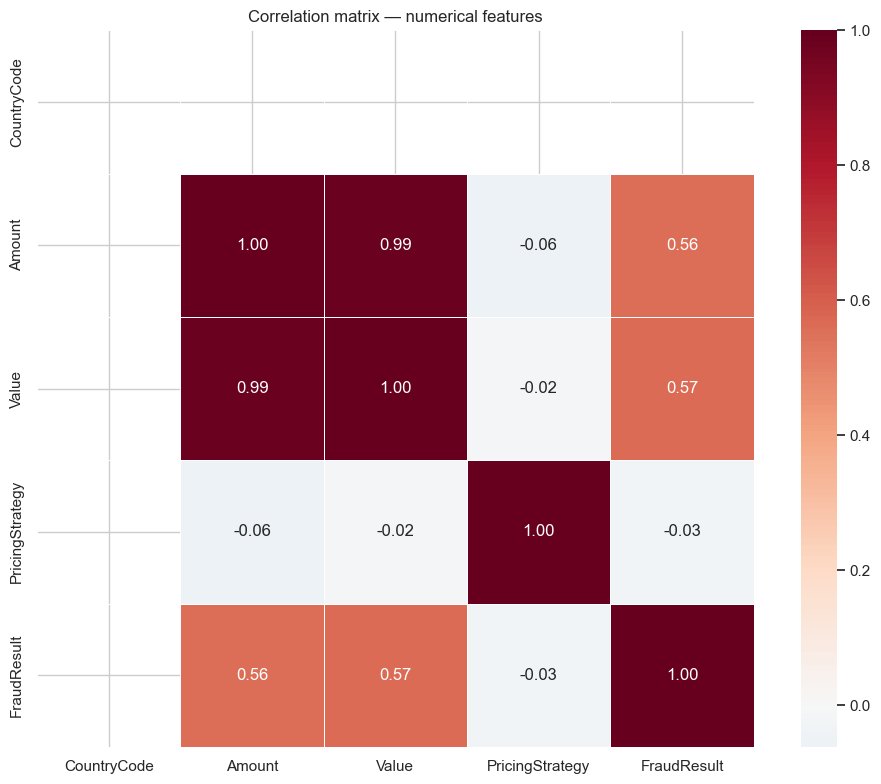

In [8]:
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0,
    square=True, linewidths=0.5
)
plt.title("Correlation matrix — numerical features")
plt.tight_layout()

In [19]:
# Find highly correlated pairs
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.7:
            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

print("Highly correlated pairs (>0.7):")
for pair in high_corr:
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.3f}")

Highly correlated pairs (>0.7):
Amount - Value: 0.990


In [9]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) == 0:
    print("No missing values detected.")
else:
    missing.plot(kind="bar", figsize=(10, 4), title="Missing value counts")
    plt.tight_layout()
    print(missing)

No missing values detected.


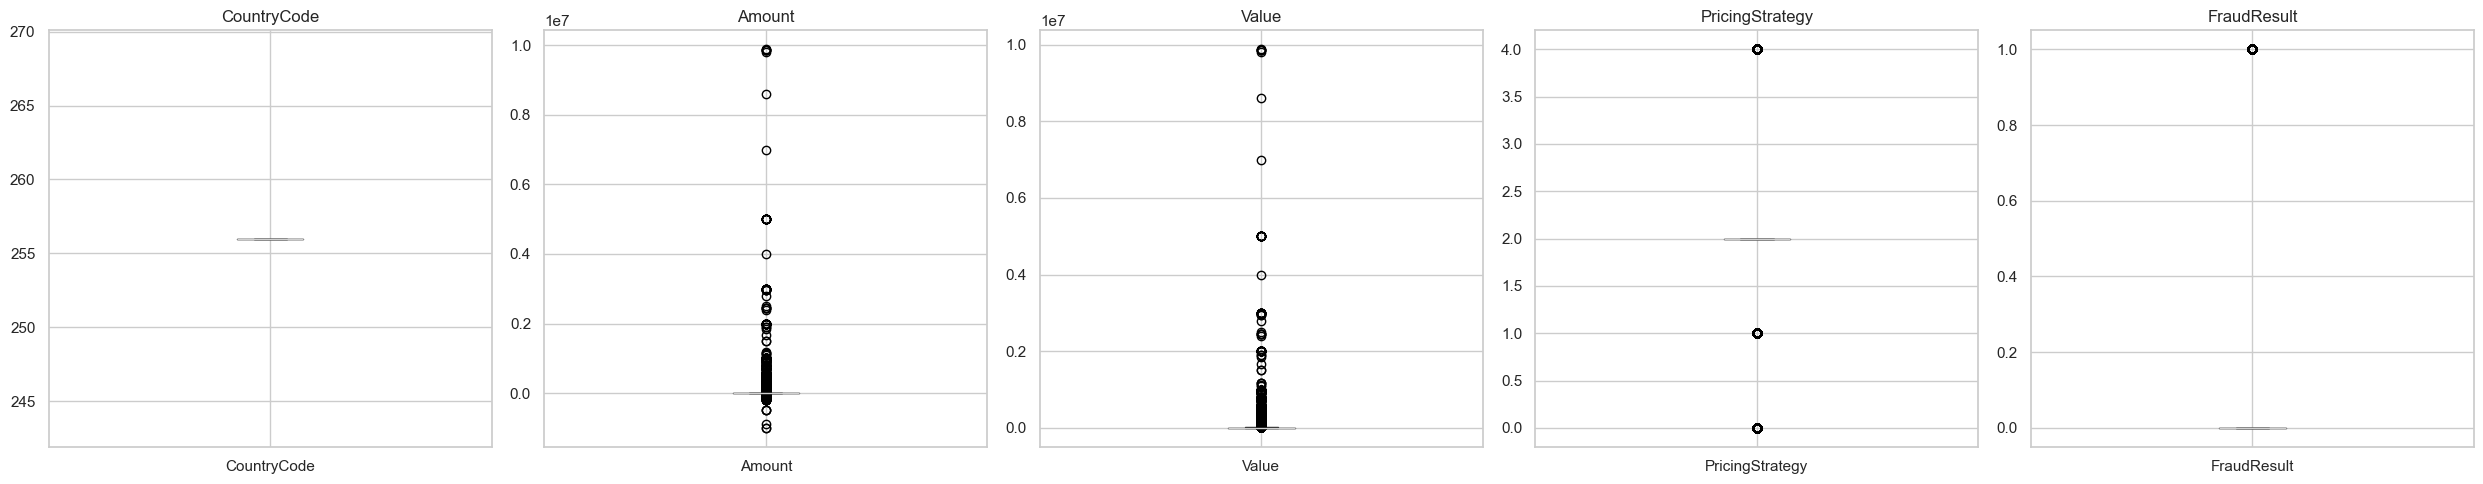

In [10]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 5))

for i, col in enumerate(num_cols):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()

In [11]:
# IQR method for outlier detection
def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return len(outliers)

print("Outlier counts by column:")
for col in num_cols:
    outlier_count = detect_outliers(df, col)
    outlier_percent = (outlier_count / len(df)) * 100
    print(f"{col}: {outlier_count} outliers ({outlier_percent:.1f}%)")

Outlier counts by column:
CountryCode: 0 outliers (0.0%)
Amount: 24441 outliers (25.5%)
Value: 9021 outliers (9.4%)
PricingStrategy: 15814 outliers (16.5%)
FraudResult: 193 outliers (0.2%)


## Key Insights

1. **Amount is extremely right-skewed (skewness = 51.10) with negative values present.**
   Standard log transformation will fail on negatives. The pipeline will apply
   signed log: `sign(x) * log1p(|x|)`. RobustScaler will handle the remaining
   outlier influence during scaling.

2. **Amount and Value are near-perfectly correlated (r = 0.990).**
   Value is the absolute of Amount. Keeping both is redundant. `Value` is
   dropped before the pipeline. All downstream modeling uses `Amount` only.

3. **Dataset spans only 90 days (Nov 2018 – Feb 2019).**
   Temporal split set at Jan 29, 2019 (~75/15 day split). This is a known
   limitation — model stability over longer time horizons is unvalidated.
   Snapshot date for RFM: 2019-02-14.

4. **Three features carry zero predictive information.**
   `CountryCode` and `CurrencyCode` are constants (single value across all rows).
   `TransactionId`, `BatchId`, `AccountId`, `SubscriptionId` are identifiers
   with no signal. All dropped before feature engineering.

5. **One customer (CustomerId_7343) accounts for 4.3% of all transactions.**
   Aggregate features will be dominated by this customer. Per-customer
   features will be computed but this anomaly is flagged for monitoring.
   No removal — the behavior is legitimate transaction data.

In [2]:
import logging
logging.basicConfig(level=logging.INFO)

import pandas as pd
from src.config import RAW_FILE
from src.rfm import generate_proxy_labels

df_raw = pd.read_csv(RAW_FILE)
labels_df = generate_proxy_labels(df_raw)

print(labels_df["is_high_risk"].value_counts())
print(f"\nHigh-risk rate: {labels_df['is_high_risk'].mean()*100:.1f}%")

INFO:src.rfm:============================================================
INFO:src.rfm:Starting proxy label generation
INFO:src.rfm:  Snapshot date  : 2019-02-14
INFO:src.rfm:  Train cutoff   : 2019-01-29
INFO:src.rfm:  N clusters     : 3
INFO:src.rfm:============================================================
INFO:src.rfm:Training window filter: 76,820 / 95,662 transactions retained (cutoff: 2019-01-29)
INFO:src.rfm:RFM computed for 3,259 customers
Recency  — mean: 40.9 days, max: 90 days
Frequency — mean: 23.6 txns, max: 4091
Monetary  — mean: 161007.05, max: 50858900.00
INFO:src.rfm:RFM features scaled with RobustScaler
INFO:src.rfm:KMeans converged in 2 iterations | Inertia: 237213.67
INFO:src.rfm:Cluster summary:
 cluster  mean_Recency  mean_Frequency  mean_Monetary  n_customers
       0     40.934255       23.498310   1.242122e+05         3255
       1     49.000000      205.000000   5.085890e+07            1
       2     38.666667       42.666667   2.318416e+07            3
INF

is_high_risk
1    3255
0       4
Name: count, dtype: int64

High-risk rate: 99.9%


In [1]:
import importlib
import src.rfm
importlib.reload(src.rfm)  # force reload — kills cached module

from src.rfm import filter_training_window, compute_rfm, cap_rfm_outliers, scale_rfm
import pandas as pd
import numpy as np
from src.config import RAW_FILE

df_raw   = pd.read_csv(RAW_FILE)
train_df = filter_training_window(df_raw)
rfm      = compute_rfm(train_df)

print("=== BEFORE capping ===")
print(rfm[["Recency", "Frequency", "Monetary"]].describe())
print(f"\nMonetary max before cap: {rfm['Monetary'].max():,.2f}")

rfm_capped = cap_rfm_outliers(rfm)

print("\n=== AFTER capping ===")
print(rfm_capped[["Recency", "Frequency", "Monetary"]].describe())
print(f"\nMonetary max after cap:  {rfm_capped['Monetary'].max():,.2f}")
print(f"Frequency max after cap: {rfm_capped['Frequency'].max():,.2f}")

=== BEFORE capping ===
           Recency    Frequency      Monetary
count  3259.000000  3259.000000  3.259000e+03
mean     40.934643    23.571648  1.610071e+05
std      22.401267    97.664498  1.215920e+06
min      16.000000     1.000000  0.000000e+00
25%      19.000000     2.000000  4.667500e+03
50%      34.000000     6.000000  2.600000e+04
75%      58.000000    18.000000  8.000000e+04
max      90.000000  4091.000000  5.085890e+07

Monetary max before cap: 50,858,900.00

=== AFTER capping ===
           Recency    Frequency      Monetary
count  3259.000000  3259.000000  3.259000e+03
mean     40.934643    20.090169  1.123874e+05
std      22.401267    38.046372  2.880433e+05
min      16.000000     1.000000  0.000000e+00
25%      19.000000     2.000000  4.667500e+03
50%      34.000000     6.000000  2.600000e+04
75%      58.000000    18.000000  8.000000e+04
max      90.000000   242.420000  2.002604e+06

Monetary max after cap:  2,002,604.00
Frequency max after cap: 242.42


In [3]:
importlib.reload(src.rfm)
from src.rfm import (
    filter_training_window, compute_rfm, cap_rfm_outliers,
    scale_rfm, cluster_customers, identify_high_risk_cluster
)
import numpy as np

df_raw   = pd.read_csv(RAW_FILE)
train_df = filter_training_window(df_raw)
rfm      = compute_rfm(train_df)
rfm      = cap_rfm_outliers(rfm)

# Check log transform is happening inside scale_rfm
rfm_scaled, scaler = scale_rfm(rfm)

print("=== SCALED ARRAY STATS ===")
print(f"Shape: {rfm_scaled.shape}")
print(f"Col 0 (Recency)   — min: {rfm_scaled[:,0].min():.2f}, max: {rfm_scaled[:,0].max():.2f}")
print(f"Col 1 (Frequency) — min: {rfm_scaled[:,1].min():.2f}, max: {rfm_scaled[:,1].max():.2f}")
print(f"Col 2 (Monetary)  — min: {rfm_scaled[:,2].min():.2f}, max: {rfm_scaled[:,2].max():.2f}")

kmeans, labels = cluster_customers(rfm_scaled)

print("\n=== CLUSTER DISTRIBUTION ===")
unique, counts = np.unique(labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} customers ({count/len(labels)*100:.1f}%)")

high_risk_cluster, summary = identify_high_risk_cluster(rfm, labels)
print(f"\nHigh-risk cluster: {high_risk_cluster}")
print(summary[["cluster", "mean_Recency", "mean_Frequency", 
               "mean_Monetary", "n_customers", "risk_score"]].to_string())

=== SCALED ARRAY STATS ===
Shape: (3259, 3)
Col 0 (Recency)   — min: -0.46, max: 1.44
Col 1 (Frequency) — min: -0.31, max: 14.78
Col 2 (Monetary)  — min: -3.58, max: 1.53


High-risk cluster is 84.5% of customers. Majority are labeled high-risk — review cluster quality.



=== CLUSTER DISTRIBUTION ===
Cluster 0: 403 customers (12.4%)
Cluster 1: 102 customers (3.1%)
Cluster 2: 2754 customers (84.5%)

High-risk cluster: 2
   cluster  mean_Recency  mean_Frequency  mean_Monetary  n_customers     risk_score
0        0     24.012407       61.759305  281342.476427          403 -281380.223325
1        1     24.166667      191.714314  741107.911765          102 -741275.459412
2        2     44.031954        7.636166   64377.790487         2754  -64341.394699


In [5]:
pd.Series(labels).value_counts()

2    2754
0     403
1     102
Name: count, dtype: int64

In [7]:
importlib.reload(src.rfm)
from src.rfm import generate_proxy_labels
import pandas as pd
from src.config import RAW_FILE

df_raw    = pd.read_csv(RAW_FILE)
labels_df = generate_proxy_labels(df_raw)

print(labels_df["is_high_risk"].value_counts())
print(f"\nHigh-risk rate: {labels_df['is_high_risk'].mean()*100:.1f}%")

High-risk rate 84.5% is too high — clusters are not separating well. Review preprocessing.


is_high_risk
1    2754
0     505
Name: count, dtype: int64

High-risk rate: 84.5%


In [8]:
import pandas as pd
from src.config import RAW_FILE, ARTIFACTS_DIR

rfm_labeled = pd.read_csv(ARTIFACTS_DIR / "rfm_with_labels.csv")

print("=== HIGH RISK customers (is_high_risk=1) ===")
print(rfm_labeled[rfm_labeled["is_high_risk"]==1][
    ["Recency","Frequency","Monetary"]
].describe().round(2))

print("\n=== LOW RISK customers (is_high_risk=0) ===")
print(rfm_labeled[rfm_labeled["is_high_risk"]==0][
    ["Recency","Frequency","Monetary"]
].describe().round(2))

=== HIGH RISK customers (is_high_risk=1) ===
       Recency  Frequency    Monetary
count  2754.00    2754.00     2754.00
mean     44.03       7.64    64377.79
std      22.43       7.49   211264.08
min      16.00       1.00        0.00
25%      23.00       2.00     3000.00
50%      40.00       5.00    17800.00
75%      61.00      11.00    48100.00
max      90.00      34.00  2002604.00

=== LOW RISK customers (is_high_risk=0) ===
       Recency  Frequency    Monetary
count   505.00     505.00      505.00
mean     24.04      88.01   374205.99
std      12.59      59.84   459629.16
min      16.00      30.00        0.00
25%      16.00      44.00    90600.00
50%      19.00      63.00   220000.00
75%      26.00     108.00   415395.00
max      82.00     242.42  2002604.00
